In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import mdtraj as md
import numpy as np
import seaborn as sns
import torch
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "svg.fonttype": "none",
})

# Purple theme colors from seaborn
PURPLE_PALETTE = sns.color_palette("Purples", n_colors=10)
RAMA_CMAP = "BuPu"

In [13]:
# --- Topology ---
PDB_PATH = Path(
    "../data/sequential-boltzmann-generators-data/"
    "GYDPETGTWG_310K/GYDPETGTWG_310K.pdb"
)
SEQUENCE = "GYDPETGTWG"  # Chignolin
N_ATOMS = 138  # From PDB file

# --- Ground truth test data ---
TEST_DATA_PATH = Path(
    "../data/sequential-boltzmann-generators-data/"
    "GYDPETGTWG_310K/GYDPETGTWG_310K_test.npy"
)

# --- Training data for normalization ---
TRAIN_DATA_PATH = Path(
    "../data/sequential-boltzmann-generators-data/"
    "GYDPETGTWG_310K/GYDPETGTWG_310K_train.npy"
)

# --- Sample file ---
SAMPLES_PT_PATH = Path("data/chignolin_samples.pt")

# --- Ramachandran plot settings ---
RAMA_BINS = 75

# --- Resampling ---
MAX_SAMPLES = 200000
CLIP_QUANTILE = 0.002
RESAMPLE_N = None

# --- Energy ---
ENERGY_DEVICE = "cuda"
ENERGY_BATCH_SIZE = 1000

In [3]:
def apply_in_ticks(ax):
    """Apply inward-pointing tick marks with length=6 to all sides."""
    ax.tick_params(direction="in", length=6, top=True, right=True, left=True, bottom=True)


def load_samples_dict(pt_path: Path) -> dict:
    """Load samples dictionary from .pt file."""
    d = torch.load(pt_path, map_location="cpu", weights_only=False)
    required = {"prior_samples", "proposal_samples", "proposal_log_q"}
    if not required.issubset(d):
        raise ValueError(f"{pt_path} missing keys {required - set(d)}")
    return d


def coerce_to_xyz(samples, n_atoms):
    """Convert samples to (N, n_atoms, 3) shape."""
    if isinstance(samples, torch.Tensor):
        samples = samples.cpu().numpy()
    samples = np.asarray(samples)

    if samples.ndim == 3:
        return samples
    if samples.ndim == 2:
        return samples.reshape(-1, n_atoms, 3)

    raise ValueError("Unrecognized sample shape")


def compute_std_from_training_data(path: Path) -> float:
    """Compute standard deviation of training data for position scaling."""
    x = np.load(path)
    x = x - x.mean(axis=1, keepdims=True)
    return float(x.std())

In [4]:
def get_phi_psi_with_labels(samples_xyz, topology):
    """Extract phi/psi dihedral angles with residue labels."""
    traj = md.Trajectory(samples_xyz, topology)

    phi_idx, phis = md.compute_phi(traj)
    psi_idx, psis = md.compute_psi(traj)

    phi_labels = [
        f"{topology.atom(int(i1)).residue.name}{topology.atom(int(i1)).residue.resSeq}"
        for (_, i1, _, _) in phi_idx
    ]
    psi_labels = [
        f"{topology.atom(int(i2)).residue.name}{topology.atom(int(i2)).residue.resSeq}"
        for (_, _, i2, _) in psi_idx
    ]

    return phis, psis, phi_labels, psi_labels


def get_all_residue_phi_psi(samples_xyz, topology):
    """Get phi/psi for all residues that have both angles defined."""
    phis, psis, phi_labels, psi_labels = get_phi_psi_with_labels(samples_xyz, topology)
    
    # Find residues that have both phi and psi
    phi_set = set(phi_labels)
    psi_set = set(psi_labels)
    common_residues = sorted(phi_set & psi_set, key=lambda x: int(x[3:]))  # Sort by residue number
    
    result = []
    for res_label in common_residues:
        phi_idx = phi_labels.index(res_label)
        psi_idx = psi_labels.index(res_label)
        result.append((phis[:, phi_idx], psis[:, psi_idx], res_label))
    
    return result

In [5]:
def compute_importance_log_weights(log_q, energies_kT, clip_quantile=None):
    """Compute importance weights for resampling."""
    log_w = -energies_kT - log_q

    if clip_quantile is None:
        return log_w, np.ones(len(log_w), bool)

    cutoff = np.quantile(log_w, 1.0 - clip_quantile)
    mask = log_w <= cutoff
    return log_w[mask], mask


def resample_with_importance_weights(samples_xyz, log_w, n_samples=None, seed=0):
    """Resample using importance weights."""
    g = torch.Generator().manual_seed(seed)
    probs = torch.softmax(torch.tensor(log_w), dim=0)

    if n_samples is None:
        n_samples = len(samples_xyz)

    idx = torch.multinomial(probs, n_samples, replacement=True, generator=g)
    return samples_xyz[idx.numpy()]

In [6]:
def make_openmm_energy_fn(pdb_path: Path, sequence: str, device="cuda"):
    """Create an OpenMM energy function for the given molecule."""
    import openmm
    import openmm.app
    import openmm.unit

    pdb = openmm.app.PDBFile(str(pdb_path))
    forcefield = openmm.app.ForceField(
        "amber99sbildn.xml", "tip3p.xml", "amber99_obc.xml"
    )

    system = forcefield.createSystem(
        pdb.topology,
        nonbondedMethod=openmm.app.NoCutoff,
        constraints=None,
    )

    integrator = openmm.LangevinMiddleIntegrator(
        310 * openmm.unit.kelvin,  # 310K for Chignolin
        1.0 / openmm.unit.picosecond,
        1.0 * openmm.unit.femtosecond,
    )

    platform = openmm.Platform.getPlatformByName("CUDA" if device == "cuda" else "CPU")
    context = openmm.Context(system, integrator, platform)

    kT = (openmm.unit.MOLAR_GAS_CONSTANT_R * 310 * openmm.unit.kelvin).value_in_unit(
        openmm.unit.kilojoule_per_mole
    )

    def energy_fn(x_nm):
        E = np.empty(len(x_nm))
        for i, x in enumerate(x_nm):
            context.setPositions(x * openmm.unit.nanometer)
            state = context.getState(getEnergy=True)
            E[i] = state.getPotentialEnergy().value_in_unit(
                openmm.unit.kilojoule_per_mole
            ) / kT
        return E

    return energy_fn

In [7]:
# Load topology and setup energy function
topology = md.load_topology(PDB_PATH)

try:
    POSITION_SCALE = compute_std_from_training_data(TRAIN_DATA_PATH)
except FileNotFoundError:
    POSITION_SCALE = 0.162962  # Default fallback

energy_fn = make_openmm_energy_fn(PDB_PATH, SEQUENCE, ENERGY_DEVICE)

print(f"Position scale: {POSITION_SCALE}")
print(f"Topology loaded with {topology.n_atoms} atoms, {topology.n_residues} residues")

Position scale: 0.34525004029273987
Topology loaded with 138 atoms, 10 residues


In [8]:
def load_test_data(test_data_path, seed=0):
    """Load ground truth test data from .npy file."""
    test_samples = np.load(test_data_path)
    
    # Subsample if needed
    if MAX_SAMPLES and len(test_samples) > MAX_SAMPLES:
        idx = np.random.default_rng(seed).choice(len(test_samples), MAX_SAMPLES, replace=False)
        test_samples = test_samples[idx]
    
    # Return samples normalized for phi/psi computation
    return test_samples / POSITION_SCALE


# Load ground truth
samples_gt = load_test_data(TEST_DATA_PATH, seed=0)
print(f"Loaded {len(samples_gt)} ground truth samples")

# Get phi/psi for all residues
gt_residue_data = get_all_residue_phi_psi(samples_gt, topology)
print(f"Found {len(gt_residue_data)} residues with both phi and psi angles:")
for phi, psi, label in gt_residue_data:
    print(f"  {label}")

Loaded 20000 ground truth samples
Found 8 residues with both phi and psi angles:
  TYR2
  ASP3
  PRO4
  GLU5
  THR6
  GLY7
  THR8
  TRP9


In [9]:
def load_resampled_samples(pt_path, seed=0):
    """Load proposal samples and compute resampled samples."""
    d = load_samples_dict(pt_path)
    xyz = coerce_to_xyz(d["proposal_samples"], N_ATOMS)
    log_q = d["proposal_log_q"].cpu().numpy()
    
    if MAX_SAMPLES and len(xyz) > MAX_SAMPLES:
        idx = np.random.default_rng(seed).choice(len(xyz), MAX_SAMPLES, replace=False)
        xyz, log_q = xyz[idx], log_q[idx]
    
    # Compute energies on proposal samples (unnormalized)
    print("Computing energies on proposal samples...")
    proposal_energies = energy_fn((xyz * POSITION_SCALE).astype(np.float32))
    
    # Compute importance weights and resample
    log_w, mask = compute_importance_log_weights(log_q, proposal_energies, CLIP_QUANTILE)
    resampled_xyz = resample_with_importance_weights(xyz[mask], log_w, RESAMPLE_N, seed)
    
    return resampled_xyz


# Load resampled samples
samples_resampled = load_resampled_samples(SAMPLES_PT_PATH, seed=0)
print(f"Loaded {len(samples_resampled)} resampled samples")

# Get phi/psi for all residues
resampled_residue_data = get_all_residue_phi_psi(samples_resampled, topology)
print(f"Found {len(resampled_residue_data)} residues with both phi and psi angles")

Computing energies on proposal samples...
Loaded 199600 resampled samples
Found 8 residues with both phi and psi angles


In [10]:
def rama_hist(phi, psi):
    """Compute 2D histogram for Ramachandran plot."""
    h, _, _ = np.histogram2d(
        phi, psi, bins=RAMA_BINS, range=[[-np.pi, np.pi], [-np.pi, np.pi]]
    )
    return h


# Compute global max for consistent colorbar across all Rama plots
all_rama_pairs = []
for phi, psi, _ in gt_residue_data:
    all_rama_pairs.append((phi, psi))
for phi, psi, _ in resampled_residue_data:
    all_rama_pairs.append((phi, psi))

global_vmax = max(rama_hist(p, q).max() for p, q in all_rama_pairs)
global_norm = LogNorm()

cbar_ticks = np.array([
    np.exp(-6) * global_vmax,
    np.exp(-4) * global_vmax,
    np.exp(-2) * global_vmax,
    global_vmax,
])

print(f"Global vmax for colorbar: {global_vmax}")

Global vmax for colorbar: 3470.0


/tmp/ipykernel_3974651/944116249.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


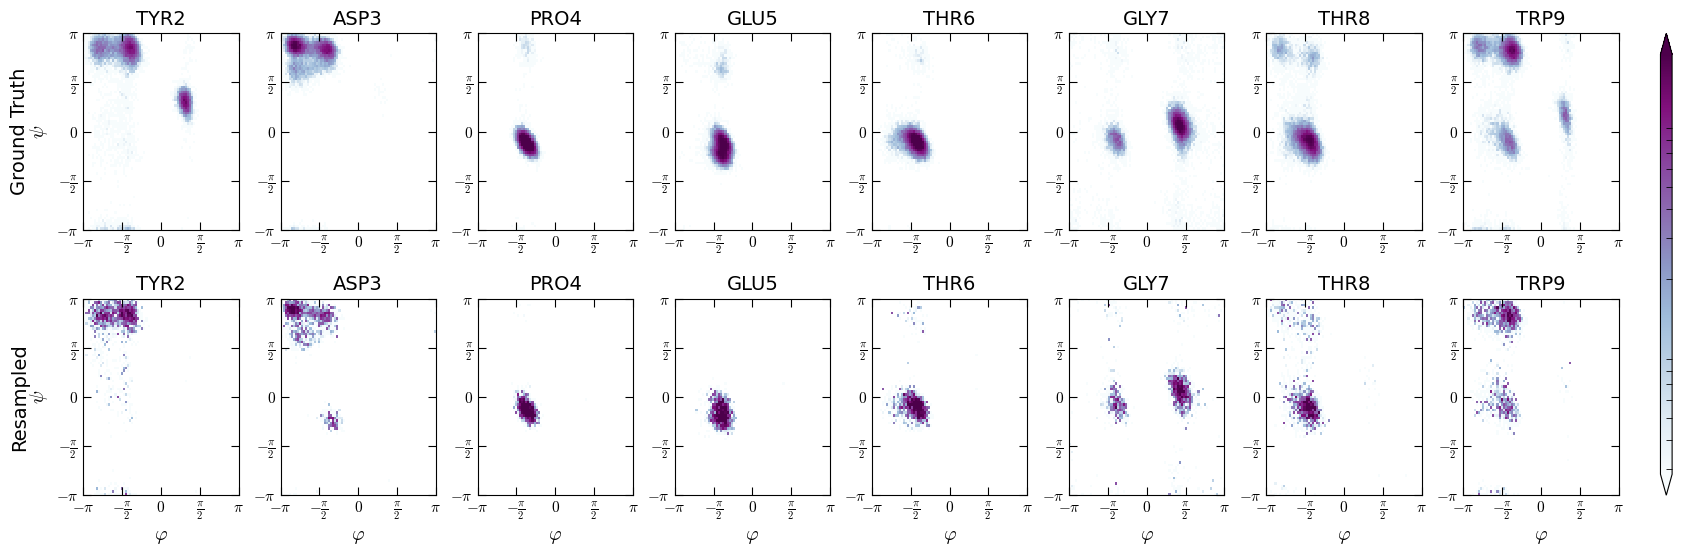

In [14]:
# Create figure with 2 rows and N+1 columns (residues + colorbar on right)
n_residues = len(gt_residue_data)

fig = plt.figure(figsize=(2.5 * n_residues + 0.5, 6))

# GridSpec: 2 rows, n_residues + 1 columns (residues + colorbar on right)
gs = GridSpec(
    2, n_residues + 1,
    width_ratios=[1] * n_residues + [0.075],
    wspace=0.3,
    hspace=0.35
)

# Pi-based tick labels
ticks = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
tick_labels = [
    r"$-\pi$",
    r"$-\frac{\pi}{2}$",
    r"$0$",
    r"$\frac{\pi}{2}$",
    r"$\pi$"
]

# ============== ROW 1: Ground Truth ==============
gt_axes = []
for col, (phi, psi, label) in enumerate(gt_residue_data):
    ax = fig.add_subplot(gs[0, col])  # No offset needed, colorbar is on right
    im = ax.hist2d(
        phi, psi,
        bins=RAMA_BINS,
        range=[[-np.pi, np.pi], [-np.pi, np.pi]],
        cmap=RAMA_CMAP,
        norm=global_norm,
        density=True,
    )[3]

    ax.set_title(label)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(tick_labels)
    ax.set_yticklabels(tick_labels)

    if col == 0:
        ax.set_ylabel(r"$\psi$")
    apply_in_ticks(ax)
    gt_axes.append((ax, im))

# Add row label
gt_axes[0][0].annotate(
    "Ground Truth", xy=(-0.35, 0.5), xycoords="axes fraction",
    fontsize=14, ha="right", va="center", rotation=90
)

# ============== ROW 2: Resampled ==============
resampled_axes = []
for col, (phi, psi, label) in enumerate(resampled_residue_data):
    ax = fig.add_subplot(gs[1, col])  # No offset needed, colorbar is on right
    im = ax.hist2d(
        phi, psi,
        bins=RAMA_BINS,
        range=[[-np.pi, np.pi], [-np.pi, np.pi]],
        cmap=RAMA_CMAP,
        norm=global_norm,
        density=True,
    )[3]

    ax.set_title(label)
    ax.set_xlabel(r"$\varphi$")
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(tick_labels)
    ax.set_yticklabels(tick_labels)

    if col == 0:
        ax.set_ylabel(r"$\psi$")
    apply_in_ticks(ax)
    resampled_axes.append((ax, im))

# Add row label
resampled_axes[0][0].annotate(
    "Resampled", xy=(-0.35, 0.5), xycoords="axes fraction",
    fontsize=14, ha="right", va="center", rotation=90
)

# ============== COLORBAR ==============
# Create colorbar spanning both rows on the right with triangular tips
ax_cbar = fig.add_subplot(gs[:, -1])
cbar = fig.colorbar(
    resampled_axes[-1][1], cax=ax_cbar, ticks=cbar_ticks,
    extend='both', extendfrac=0.05
)

cbar.ax.tick_params(direction="in", which='both', length=4)

plt.tight_layout()
plt.savefig("figures/chignolin_ramachandran.pdf", bbox_inches="tight")
plt.show()